# Superconductor T_c Prediction: Results Summary

This notebook provides a self-contained executive summary of the key 
findings from the EDA and modeling phases. All results are generated 
dynamically from the data and the trained pipeline.

In [6]:
import sys
sys.path.append("..")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import SuperconductorDataLoader
from src.pipeline import Pipeline
from src.models import LinearRegressionModel, RandomForestModel

sns.set_theme(style="whitegrid")

# load data
loader = SuperconductorDataLoader("../data/raw/train.csv")
df = loader.load()

# load and merge unique_m
df_mat = pd.read_csv("../data/raw/unique_m.csv")
df_mat["critical_temp"] = df["critical_temp"]

df_mat["is_cuprate"] = (df_mat["Cu"] > 0) & (df_mat["O"] > 0)
df_mat["is_iron_pnictide"] = (df_mat["Fe"] > 0) & ((df_mat["As"] > 0) | (df_mat["Se"] > 0))
df_mat["class_label"] = "Other"
df_mat.loc[df_mat["is_cuprate"], "class_label"] = "Cuprate"
df_mat.loc[df_mat["is_iron_pnictide"], "class_label"] = "Iron Pnictide"

# merged DataFrame for later
df_merged = df.copy()
df_merged["is_cuprate"] = df_mat["is_cuprate"].values
df_merged["is_iron_pnictide"] = df_mat["is_iron_pnictide"].values

Loaded 21263 rows from train.csv


## 1. Dataset Overview

In [8]:
overview = pd.DataFrame({
    "Property": ["Total materials", "Features", "Target variable", "Min T_c [K]", "Max T_c [K]", "Mean T_c [K]", "Median T_c [K]"],
    "Value": [
        len(df),
        df.shape[1] - 1,
        "critical_temp (T_c) [K]",
        f"{df['critical_temp'].min():.5f}",
        f"{df['critical_temp'].max():.1f}",
        f"{df['critical_temp'].mean():.2f}",
        f"{df['critical_temp'].median():.2f}"
    ]
})
overview.style.hide(axis="index")

Property,Value
Total materials,21263
Features,81
Target variable,critical_temp (T_c) [K]
Min T_c [K],0.00021
Max T_c [K],185.0
Mean T_c [K],34.42
Median T_c [K],20.00


## 2. Material Class Distribution

In [9]:
class_summary = pd.DataFrame({
    "Class": ["Cuprates", "Iron Pnictides", "Others"],
    "Count": [
        df_mat["is_cuprate"].sum(),
        df_mat["is_iron_pnictide"].sum(),
        (~df_mat["is_cuprate"] & ~df_mat["is_iron_pnictide"]).sum()
    ]
})
class_summary["Percentage"] = (class_summary["Count"] / len(df_mat) * 100).round(1).astype(str) + "%"
class_summary["Median T_c (K)"] = [
    round(df_mat.loc[df_mat["is_cuprate"], "critical_temp"].median(), 1),
    round(df_mat.loc[df_mat["is_iron_pnictide"], "critical_temp"].median(), 1),
    round(df_mat.loc[~df_mat["is_cuprate"] & ~df_mat["is_iron_pnictide"], "critical_temp"].median(), 1)
]
class_summary.style.hide(axis="index")

Class,Count,Percentage,Median T_c (K)
Cuprates,10532,49.5%,63.100000
Iron Pnictides,1682,7.9%,20.000000
Others,9049,42.6%,4.500000


The bimodal T_c distribution reflects two fundamentally different 
superconductivity mechanisms: a low-T_c peak (~2 K) from conventional 
superconductors and a high-T_c peak (~80 K) from cuprate superconductors.

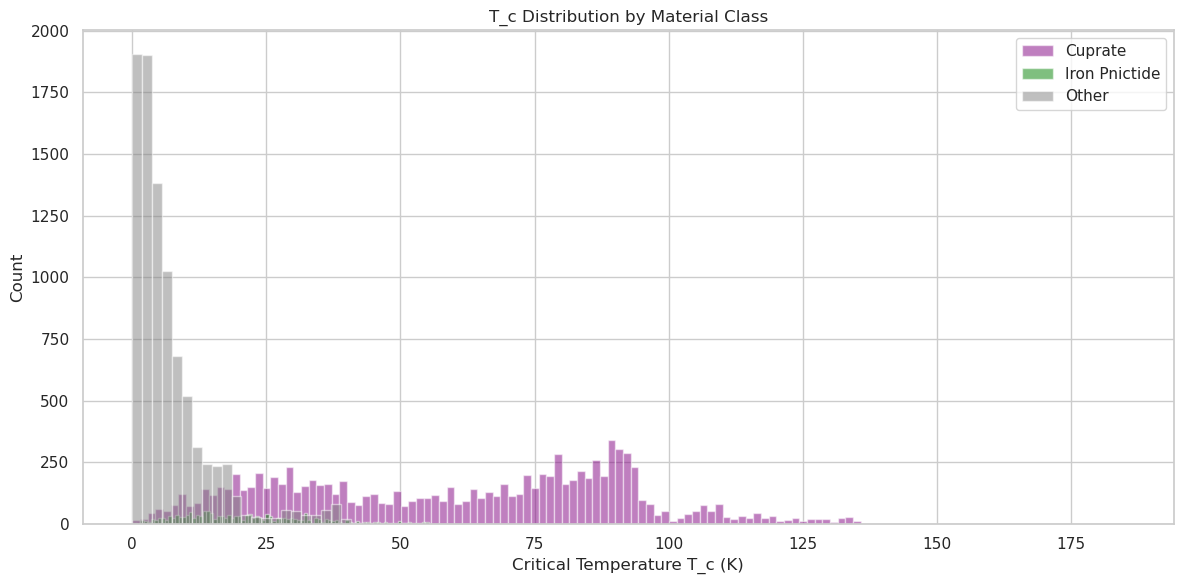

In [10]:
fig, ax = plt.subplots(figsize=(12, 6))

colors = {"Cuprate": "purple", "Iron Pnictide": "green", "Other": "gray"}

for cls, color in colors.items():
    data = df_mat.loc[df_mat["class_label"] == cls, "critical_temp"]
    ax.hist(data, bins=100, alpha=0.5, color=color, label=cls)

ax.set_xlabel("Critical Temperature T_c (K)")
ax.set_ylabel("Count")
ax.set_title("T_c Distribution by Material Class")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Top Correlated Features (EDA)

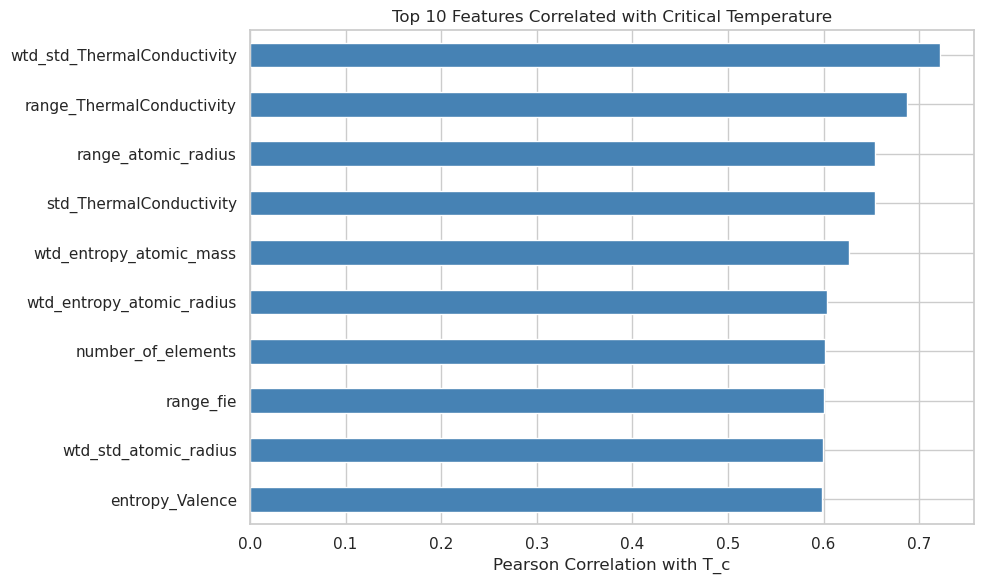

In [11]:
corr = df.corr()["critical_temp"].sort_values(ascending=False)
top10 = corr[1:11]  # exclude critical_temp itself

fig, ax = plt.subplots(figsize=(10, 6))
top10.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Pearson Correlation with T_c")
ax.set_title("Top 10 Features Correlated with Critical Temperature")
plt.tight_layout()
plt.show()

The top correlated features align with BCS theory: thermal conductivity 
(electron-phonon coupling), atomic radius (lattice overlap / DOS), 
valence electrons (band structure), and atomic mass (isotope effect).



## 4. Model Comparison

In [13]:
# Linear Regression
lr_model = LinearRegressionModel()
lr_pipeline = Pipeline(model=lr_model, data_path="../data/raw/train.csv")
lr_pipeline.run()

# Random Forest
rf_model = RandomForestModel()
rf_pipeline = Pipeline(model=rf_model, data_path="../data/raw/train.csv")
rf_pipeline.run()

# results
results = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest"],
    "RMSE (K)": [round(lr_pipeline.metrics["rmse"], 2), round(rf_pipeline.metrics["rmse"], 2)],
    "R²": [round(lr_pipeline.metrics["r2"], 4), round(rf_pipeline.metrics["r2"], 4)]
})
results.style.hide(axis="index")

Loaded 21263 rows from train.csv
Data validation passed
Loaded 21263 rows from train.csv
Data validation passed


Model,RMSE (K),R²
Linear Regression,17.710000,0.730300
Random Forest,9.660000,0.919800


The Random Forest reduces RMSE by ~45% and achieves R² ~ 0.92, confirming 
that the relationship between elemental properties and T_c is inherently 
non-linear.

## 5. Feature Importance (Random Forest)

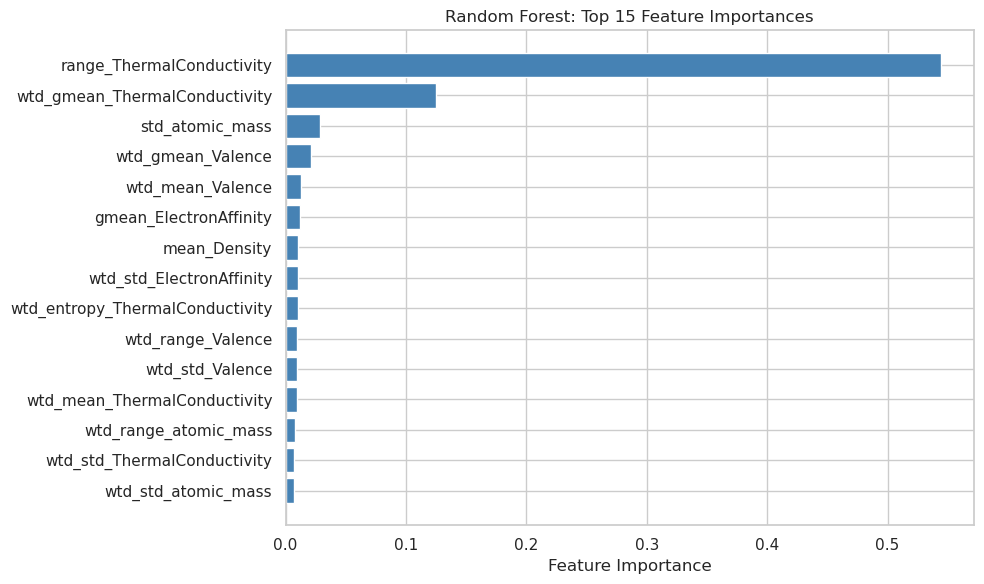

In [14]:
importances = rf_pipeline.model.model.feature_importances_
feature_names = df.drop(columns=["critical_temp"]).columns

feat_imp = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

fig, ax = plt.subplots(figsize=(10, 6))
top15 = feat_imp.head(15)
ax.barh(range(len(top15)), top15["importance"].values, color="steelblue")
ax.set_yticks(range(len(top15)))
ax.set_yticklabels(top15["feature"].values)
ax.invert_yaxis()
ax.set_xlabel("Feature Importance")
ax.set_title("Random Forest: Top 15 Feature Importances")
plt.tight_layout()
plt.show()



`range_ThermalConductivity` dominates with an importance of 0.55,
far exceeding all other features. This contrasts with the EDA, where 
the top 10 features showed similar linear correlation magnitudes. 
The Random Forest captures non-linear and interaction effects that 
linear correlation cannot detect.

## 6. Predicted vs. Observed (by Material Class)

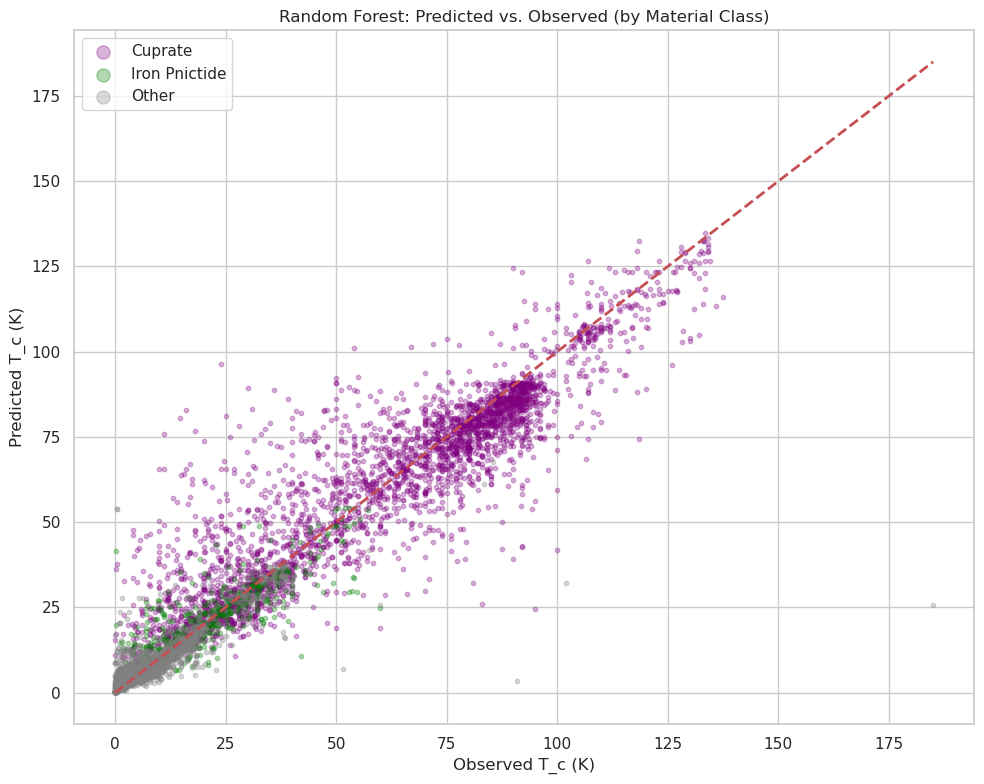

In [15]:
test_indices = rf_pipeline.y_test.index

def get_class_label(row):
    if row["is_cuprate"]:
        return "Cuprate"
    elif row["is_iron_pnictide"]:
        return "Iron Pnictide"
    else:
        return "Other"

test_classes = df_merged.loc[test_indices, ["is_cuprate", "is_iron_pnictide"]].apply(get_class_label, axis=1)

# Plot
fig, ax = plt.subplots(figsize=(10, 8))
colors = {"Cuprate": "purple", "Iron Pnictide": "green", "Other": "gray"}

for cls_name, color in colors.items():
    mask = test_classes == cls_name
    ax.scatter(
        rf_pipeline.y_test[mask],
        rf_pipeline.y_pred[mask],
        alpha=0.3, s=10, c=color, label=cls_name
    )

lim = [rf_pipeline.y_test.min(), rf_pipeline.y_test.max()]
ax.plot(lim, lim, "r--", linewidth=2)

ax.set_xlabel("Observed T_c (K)")
ax.set_ylabel("Predicted T_c (K)")
ax.set_title("Random Forest: Predicted vs. Observed (by Material Class)")
ax.legend(markerscale=3)
plt.tight_layout()
plt.show()

- **Cuprates (purple)**: Widest scatter due to heterogeneous crystal 
  structures (layer count, doping) not captured by compositional features.
- **Iron Pnictides (green)**: Moderate scatter reflecting different 
  structure types (1111, 122, 11) within the family.
- **Others (gray)**: Tightest clustering along the diagonal. Rare extreme 
  outliers likely correspond to unconventional superconductors 
  (e.g., MgB₂) misclassified by composition-based labeling.

## 7. Limitations & Future Work

### Current Limitations
- **Compositional features only**: Crystal structure, lattice parameters, 
  and doping levels are not captured but are critical determinants of T_c, 
  particularly within cuprate and iron pnictide families.
- **Composition-based classification**: Materials are grouped by elemental 
  composition rather than crystal structure type.

### Potential Improvements
1. Incorporate structural features (space group, lattice parameters, 
   layer count, coordination number)
2. Train separate models per material class
3. Explore deep learning on graph representations of crystal structures
4. Apply feature selection or dimensionality reduction to address 
   multicollinearity among thermal conductivity features

---

## 8. Conclusion

The Random Forest model achieves strong predictive performance 
(R² ~ 0.92, RMSE ~ 9.7 K) for superconducting transition temperatures 
based solely on elemental composition. The dominant importance of 
thermal conductivity features validates theoretical expectations 
regarding electron-phonon coupling as a central mechanism in 
conventional superconductivity.

Class-specific prediction gaps suggest that incorporating crystallographic 
information would further improve accuracy, particularly within 
heterogeneous families like cuprates. This project demonstrates the 
value of combining data-driven modeling with solid-state physics 
domain expertise for materials property prediction.